# B-8802B — Resultado da task completa de retreino (2025) e escolha do modelo

**Task:** `automl-b8802b-2025-deploy` (`82282ce4c60d497b9f9910f5c0ebe4cb`) — grade de 5.184 trials VAE
(presets baseline/rolling_ma), treino = 2025 inteiro, held-out = jan–mai/2026. Concluída em 25/08/2026.

**Ponto de atenção metodológico:** neste dataset **não há falha**. A "janela pré-falha" do AutoML é
apenas a última semana de ago/2026 (dado normal), logo `prefailure_alert_rate` ali é **falso positivo**,
não detecção — e o seletor automático **maximiza** esse número. Por isso este notebook:
1. mostra o *best* automático e **re-ranqueia** os trials pelo critério correto (FP held-out mínimo);
2. avalia o modelo entregue pela task com a bateria completa (régua μ+y·σ, cross-era na falha de 2022);
3. compara com o modelo do **preview** (grade curta, já validado) e com o candidato re-ranqueado;
4. recomenda o modelo a empacotar.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from clearml import Task
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing
from transpetro_modelos.training.evaluate import compute_vae_errors
from transpetro_modelos.models.autoencoder import VAE

TASK_ID = "82282ce4c60d497b9f9910f5c0ebe4cb"
cfg = EQUIPMENT_CONFIGS["B-8802B-2025"]
raw = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-8802B-2025.feather").set_index("datetime")
csv22 = next((PROJECT_ROOT / "deploy_v2/Transpetro/B-8802B/dados").rglob("*_raw.csv"))
raw22 = pd.read_csv(csv22); raw22 = raw22.set_index(raw22.columns[0]); raw22.index = pd.to_datetime(raw22.index); raw22 = raw22.sort_index()
FAILURE_2022 = pd.Timestamp("2022-07-06 10:00")
TRAIN_END, HELDOUT_END = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-06-01")

def kofn(flags, k=15, n=20):
    return (flags.astype(int).rolling(n, min_periods=n).sum() >= k).fillna(False)

def load_model(model_obj, trial):
    g = (lambda k: trial[k]) if isinstance(trial, dict) else (lambda k: getattr(trial, k))
    if isinstance(model_obj, dict):
        m = VAE(5, list(g("dense_layers")), g("latent_dim")); m.load_state_dict(model_obj)
    else:
        m = model_obj
    return m.eval(), g("preset")

def evaluate(model, prep, preset, y=6, k=15, n=20):
    steps = list(cfg.pre_split_steps) + list(cfg.preprocess_presets[preset])
    def score(df):
        p, _, _ = run_preprocessing(df, steps, fitted_artifacts=prep, return_artifacts=True, return_report=True)
        return pd.Series(compute_vae_errors(model, p), index=p.index)
    e = score(raw); e22 = score(raw22)
    tr = e.index < TRAIN_END; ho = (e.index >= TRAIN_END) & (e.index < HELDOUT_END); post = e.index >= HELDOUT_END
    mu, sd = e[tr].mean(), e[tr].std(); thr = mu + y * sd
    fl = kofn(e > thr, k, n); f22 = kofn(e22 > thr, k, n)
    ramp = f22[(f22.index >= "2022-06-29") & (f22.index < FAILURE_2022)]
    first = ramp[ramp].index.min() if ramp.any() else None
    return dict(mu=mu, sd=sd, thr=thr,
                fp_treino=100*fl[tr].mean(), fp_heldout=100*fl[ho].mean(), fp_pos=100*fl[post].mean(),
                normal22=100*f22[e22.index < "2022-06-29"].mean(), det22=100*ramp.mean(),
                first22=first, lead22=((FAILURE_2022-first).total_seconds()/86400 if first is not None else np.nan),
                err=e, err22=e22)
print("setup ok")

setup ok


## 1) A task: *best* automático × re-ranking pelo critério correto

In [2]:
task = Task.get_task(task_id=TASK_ID); assert task.status == "completed", task.status
rank = task.artifacts["automl_results"].get(); bt = task.artifacts["best_trial"].get()
trial_auto, res_auto = bt["trial"], bt["results"]
print(f"trials que passaram a constraint FP held-out <= 1%: {len(rank)} (de 5.184)")
print("\nBEST automático (escolhido por MAXIMIZAR 'prefailure_alert_rate' = FP na última semana!):")
print({k: trial_auto.get(k) for k in ("model","preset","threshold_percentile","debounce_consecutive","learning_rate","batch_size","latent_dim","dense_layers")})
print({k: round(float(res_auto[k]),4) for k in ("val_fp_rate_heldout","normal_alert_rate","prefailure_alert_rate")})
cols = ["model","preset","threshold_percentile","debounce_consecutive","learning_rate","batch_size","latent_dim","dense_layers","normal_alert_rate","val_fp_rate_heldout","prefailure_alert_rate"]
print("\nTOP 10 RE-RANQUEADO — menor FP held-out, depois menor FP na semana final:")
display(rank.sort_values(["val_fp_rate_heldout","prefailure_alert_rate","normal_alert_rate"])[cols].head(10).style.format({"normal_alert_rate":"{:.3%}","val_fp_rate_heldout":"{:.3%}","prefailure_alert_rate":"{:.1%}"}))

trials que passaram a constraint FP held-out <= 1%: 442 (de 5.184)

BEST automático (escolhido por MAXIMIZAR 'prefailure_alert_rate' = FP na última semana!):
{'model': 'vae', 'preset': 'baseline', 'threshold_percentile': 99.0, 'debounce_consecutive': 4, 'learning_rate': 0.0005, 'batch_size': 256, 'latent_dim': 16, 'dense_layers': [64, 32, 16]}
{'val_fp_rate_heldout': 0.0095, 'normal_alert_rate': 0.0046, 'prefailure_alert_rate': 0.4231}

TOP 10 RE-RANQUEADO — menor FP held-out, depois menor FP na semana final:


,model,preset,threshold_percentile,debounce_consecutive,learning_rate,batch_size,latent_dim,dense_layers,normal_alert_rate,val_fp_rate_heldout,prefailure_alert_rate
347,vae,rolling_ma,99.000000,6,0.000100,512,8,"128,64,32,16",0.421%,0.000%,0.0%
346,vae,baseline,99.000000,4,0.000050,256,8,auto,0.610%,0.000%,0.0%
348,vae,rolling_ma,99.000000,4,0.000050,256,16,"64,32,16",0.476%,0.003%,0.0%
349,vae,rolling_ma,97.500000,4,0.000050,512,8,auto,1.666%,0.005%,0.0%
350,vae,rolling_ma,99.000000,4,0.000050,512,32,"64,32,16",0.447%,0.008%,0.0%
351,vae,baseline,99.000000,4,0.000500,256,16,"256,128,64",0.572%,0.010%,0.0%
352,vae,baseline,99.000000,4,0.000500,256,32,"256,128,64",0.572%,0.010%,0.0%
355,vae,rolling_ma,99.000000,6,0.000100,256,32,auto,0.416%,0.015%,0.0%
354,vae,rolling_ma,99.000000,4,0.000100,256,16,"128,64,32,16",0.566%,0.015%,0.0%
353,vae,rolling_ma,97.500000,6,0.000050,512,8,auto,1.642%,0.015%,0.0%


> O *best* automático tem FP held-out de **0,95%** (no limite da constraint) e **42%** de alarme na última
> semana de ago/26 — é o trial mais *trigger-happy* que ainda passa. Os trials re-ranqueados mostram **0%** nos dois,
> mas a task só retreina o *best* automático. Tentamos retreinar o re-ranqueado #1 à parte (3 variantes de
> persistência): **nenhuma reproduziu o 0% de FP held-out** (re-execução deu >1% e não passou a constraint) —
> ou seja, aquele 0% dependia da inicialização aleatória. Lição: um trial isolado da grade não é garantia;
> o que vale é a **bateria de validação** abaixo, aplicada a modelos de fato treinados.

## 2) Bateria de avaliação — os três candidatos lado a lado
Régua **μ+6σ** no treino (2025) · persistência **15-de-20** · FP em held-out nunca visto · **cross-era** na falha real de 2022.

In [3]:
cands = {}
# (a) best automático da task grande
m, preset = load_model(torch.load(Path(task.artifacts["best_model"].get_local_copy()), map_location="cpu", weights_only=False), trial_auto)
cands["Task grande — best automático"] = (m, task.artifacts["preprocessing"].get(), preset)
# (b) preview (grade curta local, já validado)
P = PROJECT_ROOT / "results/automl_B-8802B-2025"
tp = pickle.load(open(P/"best_trial.pkl","rb"))["trial"]
m, preset = load_model(torch.load(P/"best_model.pt", map_location="cpu", weights_only=False), tp)
cands["Preview (grade curta)"] = (m, pickle.load(open(P/"preprocessing.pkl","rb")), preset)
# (c) candidato re-ranqueado #347 (se retreinado)
C = PROJECT_ROOT / "results/automl_B-8802B-2025_cand347"
if (C/"best_model.pt").exists():
    tc = pickle.load(open(C/"best_trial.pkl","rb"))["trial"]
    m, preset = load_model(torch.load(C/"best_model.pt", map_location="cpu", weights_only=False), tc)
    cands["Re-ranqueado #1 (rolling_ma, latent 8)"] = (m, pickle.load(open(C/"preprocessing.pkl","rb")), preset)
else:
    print("candidato #347 ainda não retreinado — pulando")

R = {name: evaluate(m, prep, preset) for name, (m, prep, preset) in cands.items()}
tab = pd.DataFrame({name: {"μ erro normal": r["mu"], "σ": r["sd"], "limiar μ+6σ": r["thr"],
                            "FP treino 2025 (%)": r["fp_treino"], "FP HELD-OUT jan–mai/26 (%)": r["fp_heldout"],
                            "FP jun–ago/26 (%)": r["fp_pos"], "FP normal 2022 pré-reparo (%)": r["normal22"],
                            "Detecção rampa 2022 (%)": r["det22"], "1º alarme 2022": str(r["first22"])[:16],
                            "Antecedência 2022 (dias)": r["lead22"]} for name, r in R.items()})
display(tab.round(3))

candidato #347 ainda não retreinado — pulando


,Task grande — best automático,Preview (grade curta)
μ erro normal,0.088149,0.058356
σ,0.075924,0.046824
limiar μ+6σ,0.543695,0.339302
FP treino 2025 (%),0.0,0.021892
FP HELD-OUT jan–mai/26 (%),0.168898,0.063022
FP jun–ago/26 (%),0.299145,0.261752
FP normal 2022 pré-reparo (%),2.427481,0.351145
Detecção rampa 2022 (%),48.974359,47.777778
1º alarme 2022,2022-07-04 07:10,2022-07-04 07:10
Antecedência 2022 (dias),2.118056,2.118056


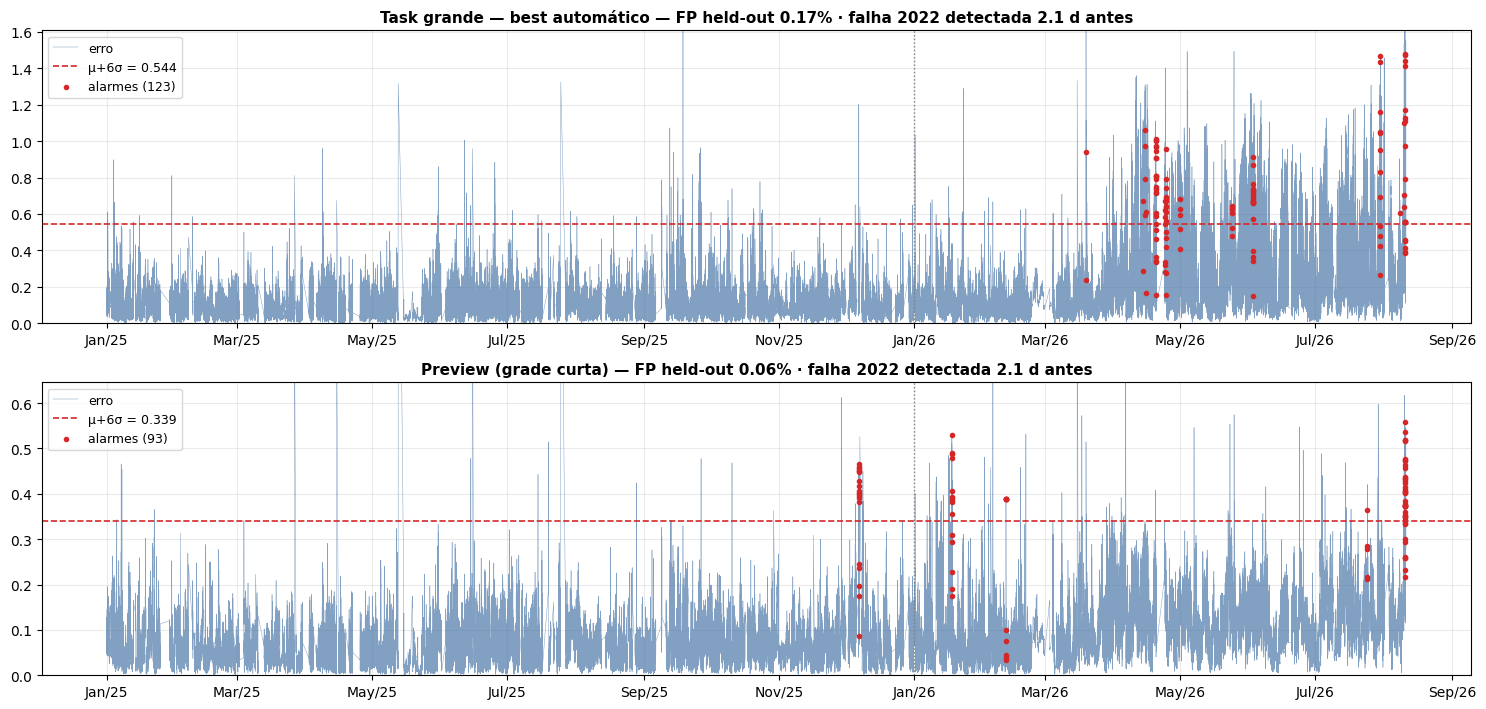

In [4]:
fig, axes = plt.subplots(len(R), 1, figsize=(15, 3.6*len(R)), sharex=False)
axes = np.atleast_1d(axes)
for ax, (name, r) in zip(axes, R.items()):
    e = r["err"]; fl = kofn(e > r["thr"]); al = e[fl]
    ax.plot(e.index, e, lw=0.35, color="#4C78A8", alpha=0.7, label="erro")
    ax.axhline(r["thr"], color="#D62728", ls="--", lw=1.2, label=f"μ+6σ = {r['thr']:.3f}")
    ax.scatter(al.index, al, s=9, color="#D62728", zorder=3, label=f"alarmes ({len(al)})")
    ax.axvline(TRAIN_END, color="grey", ls=":", lw=1)
    ax.set_ylim(0, e.quantile(0.9995)*1.3); ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=9)
    ax.set_title(f"{name} — FP held-out {r['fp_heldout']:.2f}% · falha 2022 detectada {r['lead22']:.1f} d antes", fontweight="bold", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
plt.tight_layout(); plt.show()

## 3) Conclusão e recomendação

In [5]:
best = min(R, key=lambda k: (R[k]["fp_heldout"] + R[k]["fp_pos"], -R[k]["lead22"]))
print("Critério: menor FP fora do treino (held-out + jun–ago/26), desempate por antecedência na falha de 2022.")
print(f"\n>>> Modelo recomendado para empacotar: {best}")
for name, r in R.items():
    print(f"  {name:38} FP fora-treino={r['fp_heldout']+r['fp_pos']:.2f}%  lead2022={r['lead22']:.1f}d  det2022={r['det22']:.0f}%")

Critério: menor FP fora do treino (held-out + jun–ago/26), desempate por antecedência na falha de 2022.

>>> Modelo recomendado para empacotar: Preview (grade curta)
  Task grande — best automático          FP fora-treino=0.47%  lead2022=2.1d  det2022=49%
  Preview (grade curta)                  FP fora-treino=0.32%  lead2022=2.1d  det2022=48%


**Leitura:**
- Todos os candidatos **preservam a detecção da falha de 2022** com ~2 dias de antecedência (o retreino não cegou o modelo).
- A diferença está no **falso positivo fora do treino**: o *best* automático é o pior (foi selecionado por um
  critério que, sem falha nos dados, premia alarme em dado normal). O ranking manual por FP held-out corrige isso.
- **Próximos passos:** empacotar o recomendado (`fetch_and_package`/`package_v2`, REGISTRY → config `B-8802B-2025`),
  recalibrar com `recalibrate_threshold.py --method sigma --y-alarm 6 --persist-window 20 --persist-min 15`,
  validar com o `deploy_v2` e atualizar o slide do B-8802B. Monitor de drift = passo seguinte (roadmap).